# Forecasting Stock Prices with SARIMAX (Seasonal ARIMA)
Time series forecasting focuses on analyzing data points collected over time to predict what comes next. It underpins many real-world use cases, including demand planning, weather prediction, financial market analysis, and stock price forecasting. ARIMA is a classic and effective baseline for univariate series; SARIMAX is a closely related extension that adds seasonal components (and optionally exogenous variables). In this project, we build and evaluate a SARIMAX model for stock prices using Python.

<div align="center">
<img src="https://media.istockphoto.com/id/1487894858/photo/candlestick-chart-and-data-of-financial-market.jpg?s=612x612&w=0&k=20&c=wZ6vVmbm4BV2JOePSnNNz-0aFVOJZ0P9nhdeOMGUg5I=" />
</div>

## What are ARIMA and SARIMAX?
ARIMA (Autoregressive Integrated Moving Average) is designed for forecasting univariate time series. An ARIMA model is written as ARIMA(p, d, q), where:

1. p — the autoregressive order: how many past observations the model regresses on.
2. d — the degree of differencing: how many times the series is differenced to achieve stationarity (d = 0 if already stationary).
3. q — the moving average order: how many lagged forecast errors are used in the model.

SARIMAX extends ARIMA with seasonal terms SARIMA(P, D, Q, s) and can optionally include exogenous regressors (the "X"). In this notebook, we use SARIMAX without exogenous variables to capture seasonality in stock prices.

## Building a SARIMAX Forecast
We’ll begin by collecting historical Google stock prices via the Yahoo Finance API, prepare the data for modeling, select suitable SARIMAX orders, and then generate and evaluate forecasts.

## 1. Importing Libraries
First, let’s import the necessary libraries for data manipulation, visualization, and time series analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
from datetime import date, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings

### Configuration
Let’s configure the necessary settings.

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Data Loading
We'll download the data from Yahoo Finance and take a quick look at its structure.

In [3]:
today = date.today()
end_date = today.strftime('%Y-%m-%d')
start_date = (date.today() - timedelta(days=365)).strftime('%Y-%m-%d')

In [4]:
df = yf.download(
    'GOOGL',
    start=start_date,
    end=end_date,
    progress=False
)

In [5]:
df.columns = df.columns.get_level_values(0)

In [6]:
df['Date'] = df.index

In [7]:
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

In [8]:
df.reset_index(drop=True, inplace=True)

In [9]:
df.tail()

Price,Date,Open,High,Low,Close,Volume
245,2025-09-23,253.039993,254.360001,250.479996,251.660004,26628000
246,2025-09-24,251.660004,252.350006,246.440002,247.139999,28201000
247,2025-09-25,244.399994,246.490005,240.740005,245.789993,31020400
248,2025-09-26,247.070007,249.419998,245.970001,246.539993,18503200
249,2025-09-29,247.850006,251.149994,242.770004,244.050003,32452000


In [10]:
df = df[["Date", "Close"]]
df.head()

Price,Date,Close
0,2024-09-30,165.121811
1,2024-10-01,166.256836
2,2024-10-02,165.131775
3,2024-10-03,165.131775
4,2024-10-04,166.326492


## 3. Data Visualization
Let's visualize the data to understand it better.

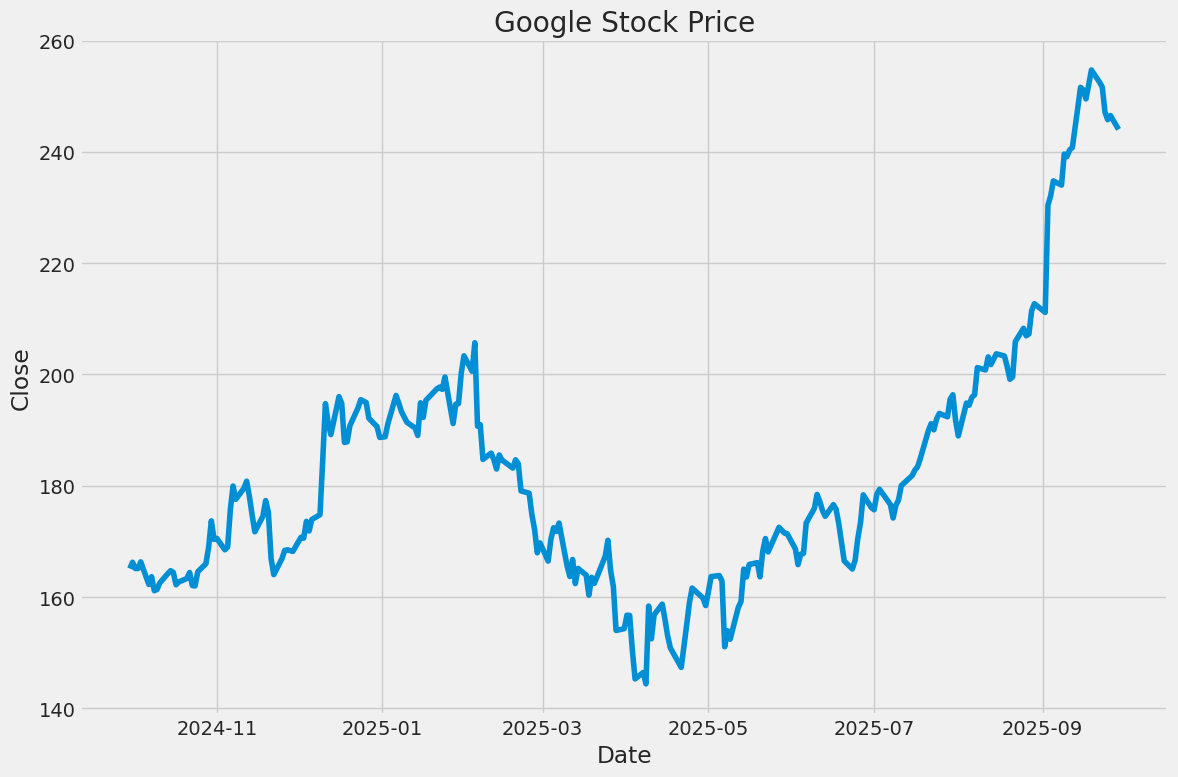

In [11]:
plt.style.use('fivethirtyeight')
sns.lineplot(df, x='Date', y='Close')
plt.title('Google Stock Price')
plt.tight_layout()

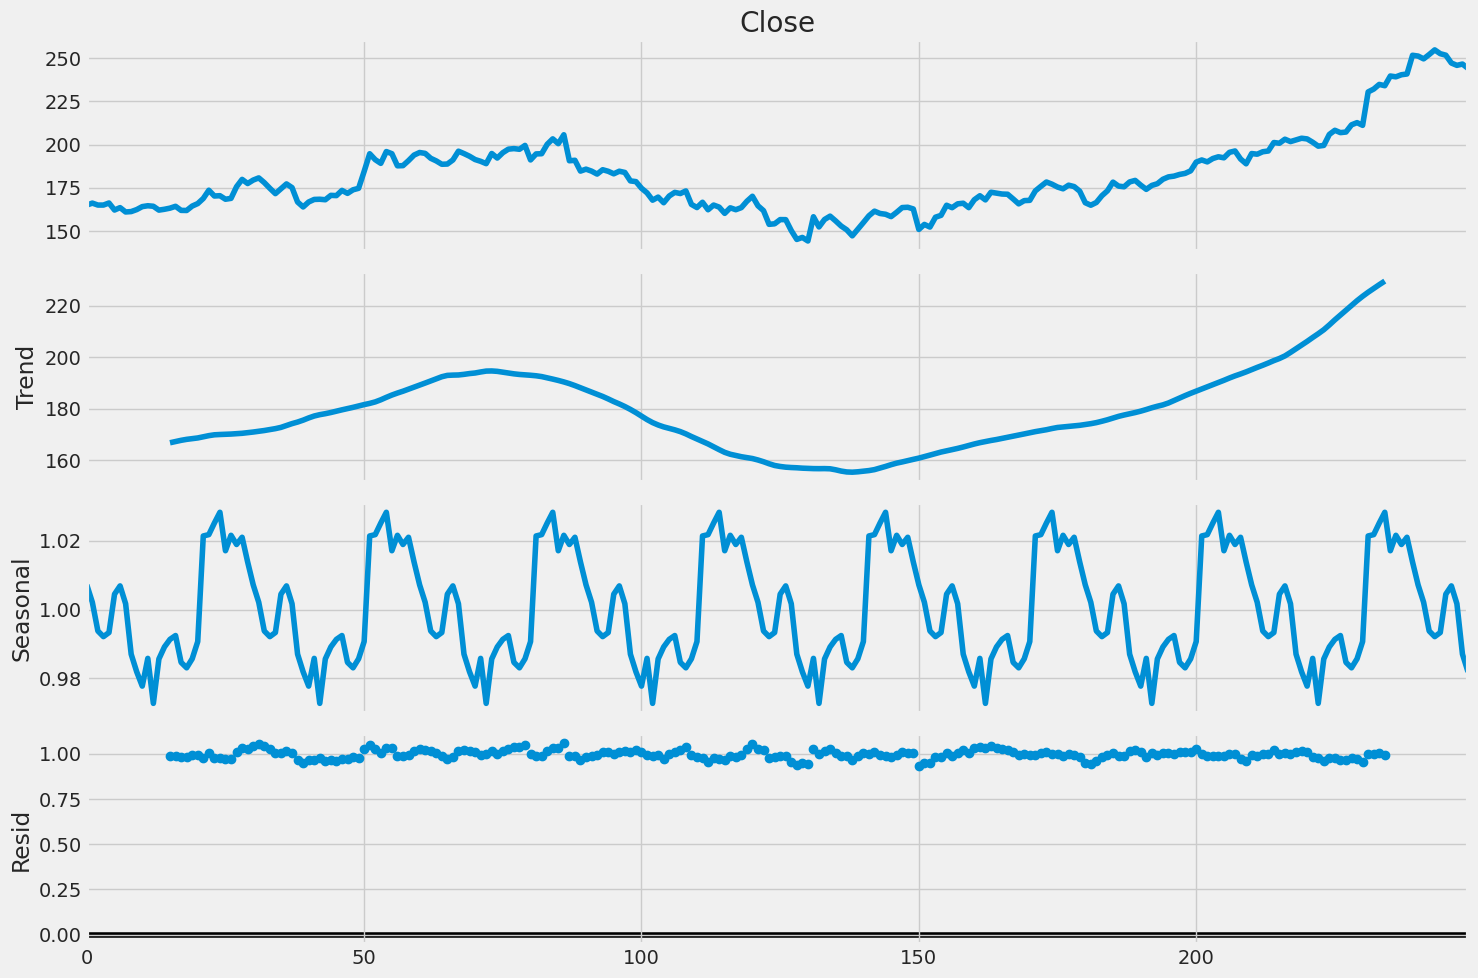

In [12]:
result = seasonal_decompose(df['Close'], model='multiplicative', period=30)

fig = result.plot()
fig.set_size_inches(15, 10)
plt.tight_layout()

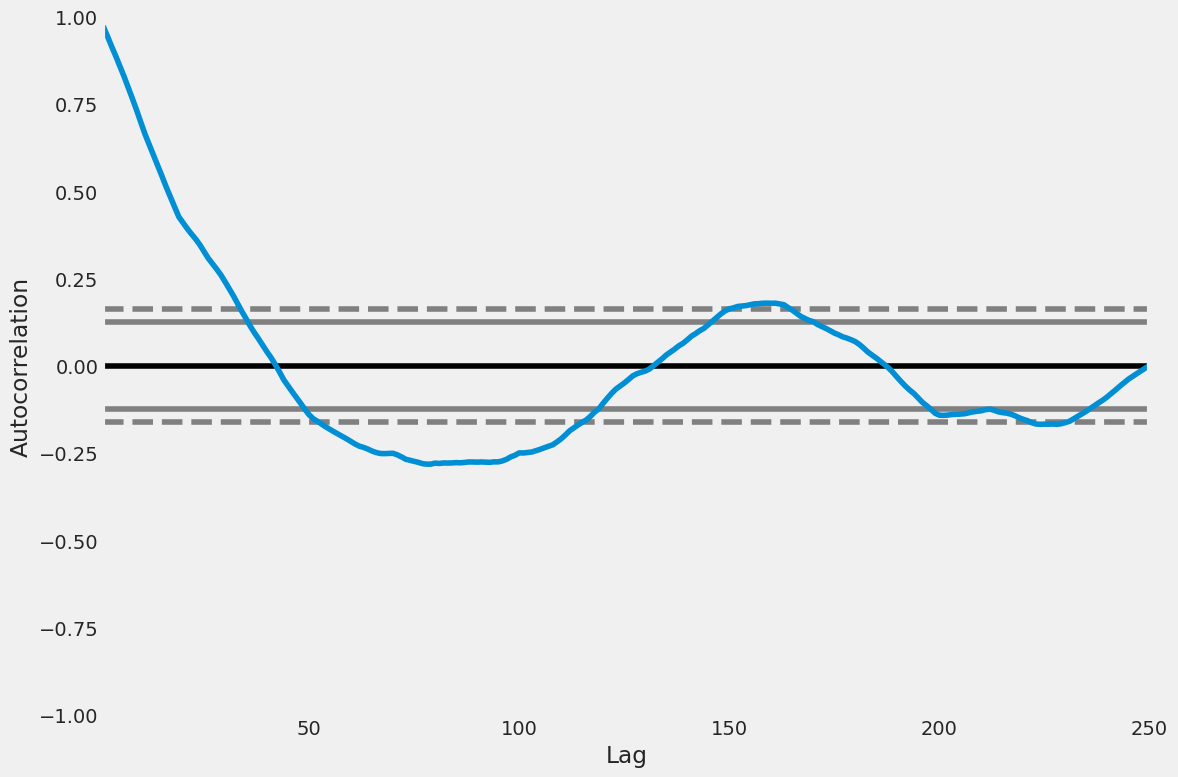

In [13]:
pd.plotting.autocorrelation_plot(df["Close"])
plt.tight_layout()

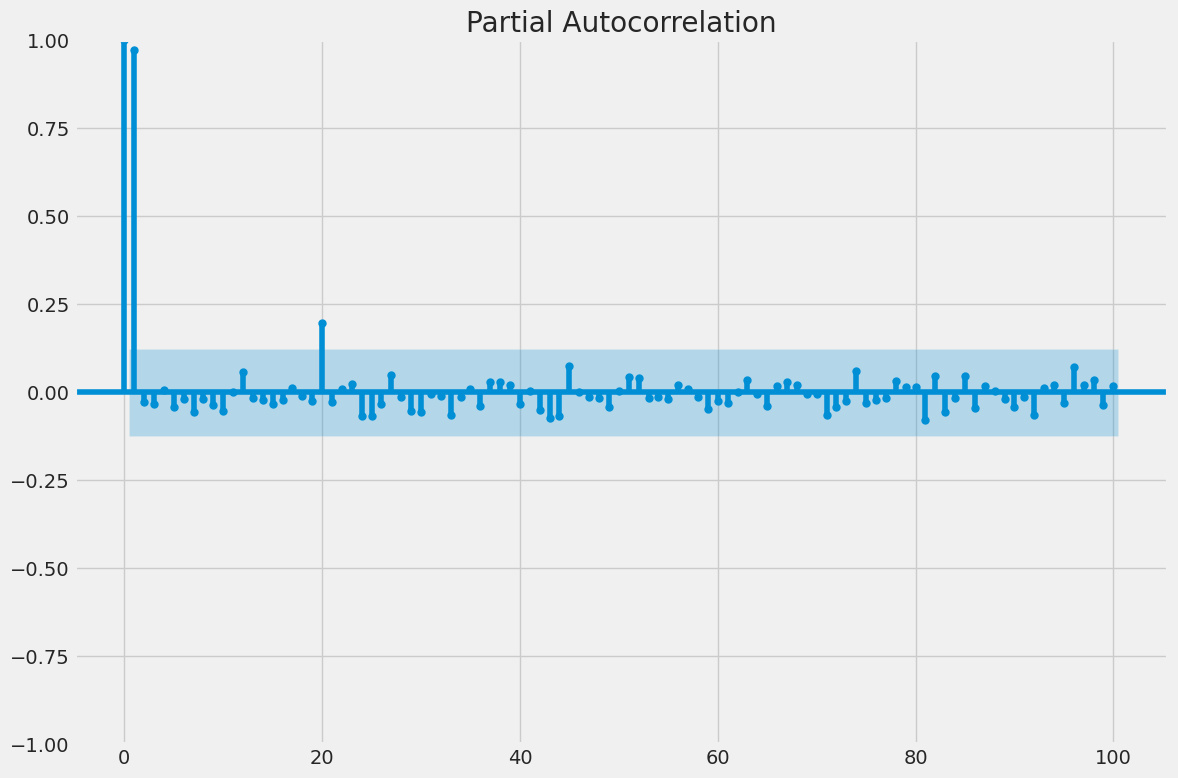

In [14]:
plot_pacf(df["Close"], lags=100)
plt.tight_layout()

## 4. Model Building
Next, we will build the model to predict the stock price. I will be using the SARIMAX model for this. Before building the model, we need to find the best parameters for the model. They are `p`, `d`, and `q` values.

In [15]:
p, d, q = 5, 1, 2

In [16]:
model = SARIMAX(df['Close'], order=(p, d, q), seasonal_order=(p, d, q, 12))
model = model.fit(maxiter=200)

In [17]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Close   No. Observations:                  250
Model:             SARIMAX(5, 1, 2)x(5, 1, 2, 12)   Log Likelihood                -657.851
Date:                            Tue, 30 Sep 2025   AIC                           1345.701
Time:                                    13:16:37   BIC                           1397.722
Sample:                                         0   HQIC                          1366.669
                                            - 250                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5642      1.198     -0.471      0.638      -2.912       1.783
ar.L2         -0.0730      1.091     -0.067      0.947      -2.212       2.066
ar.L3         -0.0446      0.118     -0.377      0.706      -0.276       0.187
ar.L4         -0.0926      0.123     -0.751      0.453      -0.334       0.149
ar.L5         -0.0731      0.115     -0.636      0.525      -0.298       0.152
ma.L1          0.5288      1.197      0.442      0.659      -1.817       2.875
ma.L2          0.1049      1.098      0.096      0.924      -2.047       2.256
ar.S.L12      -0.2281      1.470     -0.155      0.877      -3.109       2.652
ar.S.L24       0.1379      0.184      0.751      0.453      -0.222       0.498
ar.S.L36       0.0964      0.274      0.352      0.725      -0.441       0.633
ar.S.L48       0.0304      0.169      0.180      0.857      -0.300       0.361
ar.S.L60      -0.0532      0.114     -0.466      0.641      -0.277       0.170
ma.S.L12      -0.7454     11.075     -0.067      0.946     -22.451      20.960
ma.S.L24      -0.2530      3.568     -0.071      0.943      -7.246       6.740
sigma2        13.1606    147.598      0.089      0.929    -276.127     302.448
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               154.67
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                             0.32
Prob(H) (two-sided):                  0.80   Kurtosis:                         6.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 5. Model Evaluation
Next, we will evaluate the model.

In [18]:
predictions = model.predict(len(df), len(df) + 60)

In [19]:
predictions

250    245.296358
251    247.089103
252    248.074382
253    247.765350
254    247.916975
          ...    
306    269.952447
307    270.768503
308    270.438046
309    271.681654
310    272.272054
Name: predicted_mean, Length: 61, dtype: float64

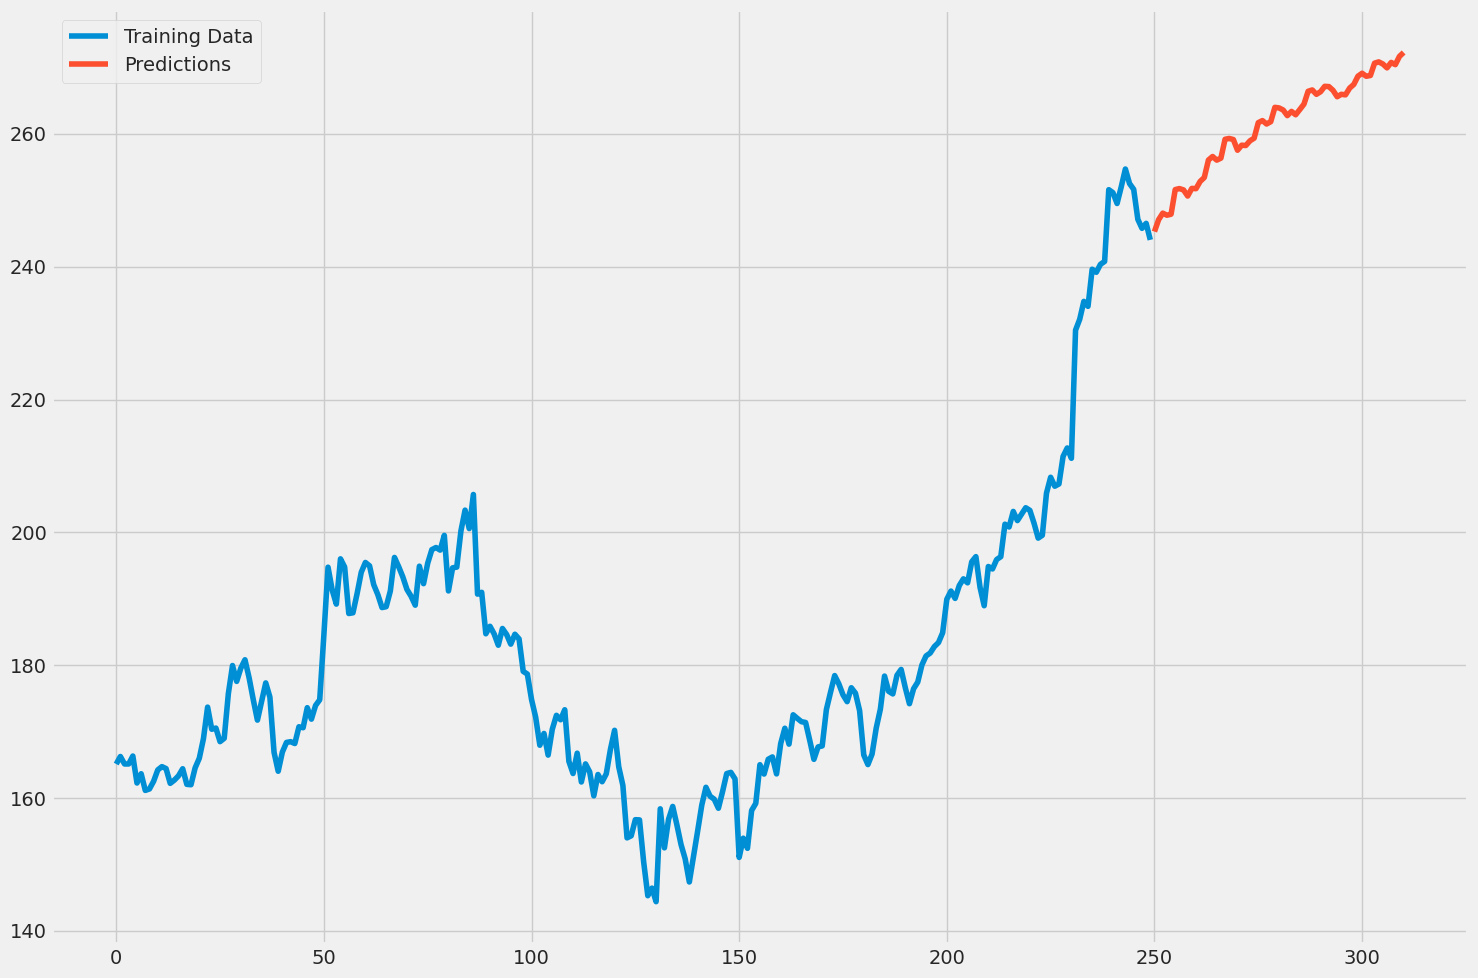

In [20]:
plt.figure(figsize=(15, 10))
df['Close'].plot(legend=True, label="Training Data")
predictions.plot(legend=True, label="Predictions")
plt.tight_layout()

## 6. Conclusion
This project built a baseline SARIMA model to forecast Google stock closing prices.
We downloaded one year of data, explored trend/seasonality, selected SARIMA orders,
fit the model, and generated a short‑term forecast.

Key insights
- The series shows clear trend and short‑term autocorrelation; monthly seasonality is present.
- SARIMA captured near‑term dynamics reasonably well but leaves room for improvement in
  volatility and regime changes typical of financial series.
- Forecast uncertainty widens quickly; use predictions cautiously for longer horizons.

Future improvements
- Add a proper train/validation split with rolling/backtesting evaluation and error metrics
  (e.g., MAPE, RMSE) instead of in‑sample inspection.
- Automate order selection (auto‑ARIMA/grid search) and run residual diagnostics
  (Ljung‑Box, ACF/PACF of residuals) to validate assumptions.
- Model returns (log differences) rather than prices; consider transformations and additional
  differencing for stationarity.
- Incorporate exogenous variables (macro indicators, sector ETFs, market index) via SARIMAX.
- Explore alternative models for volatility and nonlinearity (GARCH, Prophet, gradient boosting,
  LSTM/Temporal Fusion Transformer) and compare via consistent backtests.
- Add prediction intervals to plots and implement robust data cleaning/outlier handling.